# RF01 -Criação de um Data set de vendas com dados sintéticos

In [1]:

# Gerar o dataset no código

import pandas as pd
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


In [2]:
# Gera um dataset sintético de vendas com dados propositalmente sujos,
# incluindo valores nulos, strings sujas, datas inválidas e outliers.
#

def gerar_dataset_vendas(n_registros= 500 , seed= 100):

  random.seed(seed)
  np.random.seed(seed)
  produtos = [ 'Notebook' , 'Smartphone' , 'Tablet' , 'Monitor' , 'Teclado' , 'Mouse' ]
  precos = { 'Notebook' : 3500 , 'Smartphone' : 2200 , 'Tablet' : 1800 , 'Monitor' : 1200 , 'Teclado' : 250 , 'Mouse' : 120 }
  categorias = { "Notebook" : "Computadores" , "Smartphone" : "Celulares" , "Tablet" : "Celulares" , "Monitor" : "Computadores" , "Teclado" : "Periféricos" , "Mouse" : "Periféricos" }
  regioes = [ "Sudeste" , "Sul" , "Nordeste" , "Centro-Oeste" , "Norte" ]
  clientes = [ f"Cliente_{i: 03d}" for i in range ( 1 , 31 )]
  data_inicio = datetime( 2024 , 1 , 1 )
  dados = []
  for i in range (n_registros):
    produto = random.choice(produtos)
    quantidade = random.randint( 1 , 10 )
    preco = precos[produto]
    data = data_inicio + timedelta(days=random.randint( 0 , 364 ))

    # Inserindo dados intencionalmente sujos para limpeza

    if random.random() < 0.05 : quantidade = None # valor nulo
    if random.random() < 0.04 : preco = None # valor nulo
    if random.random() < 0.03 : produto = " " + produto # espaço extra (string suja)
    data_str = data.strftime( "%Y-%m-%d" ) if random.random() > 0.02 else "DATA INVALIDA"

    dados.append({ "id_venda" : i + 1 , "data_venda" : data_str, "cliente" : random.choice(clientes),
                    "produto" : produto, "categoria" : categorias.get(produto.strip(), "Outros" ),
                    "regiao" : random.choice(regioes), "quantidade" : quantidade, "preco_unitario" : preco })
  return pd.DataFrame(dados)

# Gerar e salvar
df_bruto = gerar_dataset_vendas()
os.makedirs( 'data/raw' , exist_ok= True )
# Adicionado para garantir que o diretório exista
df_bruto.to_csv( "data/raw/vendas.csv" , index= False )
print (f"Dataset gerado com {len (df_bruto)} registros." )
print (df_bruto.head())


Dataset gerado com 500 registros.
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-08-20  Cliente_ 17  Smartphone     Celulares   Sudeste   
1         2  2024-02-11  Cliente_ 07     Teclado   Periféricos  Nordeste   
2         3  2024-04-14  Cliente_ 14  Smartphone     Celulares       Sul   
3         4  2024-10-11  Cliente_ 21     Monitor  Computadores   Sudeste   
4         5  2024-11-04  Cliente_ 27  Smartphone     Celulares   Sudeste   

   quantidade  preco_unitario  
0         8.0          2200.0  
1         2.0           250.0  
2         5.0          2200.0  
3         8.0          1200.0  
4         1.0          2200.0  


# RF02 Inspecionar e Descrever os Dados

In [3]:


def inspecionar_dados(df_bruto):

    # Exibe informações básicas do DataFrame.

    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df_bruto.shape}")
    print(f"\nColunas: {list(df_bruto.columns)}")
    print(f"\nTipos de dados:\n{df_bruto.dtypes}")
    print(f"\nValores nulos por coluna:\n{df_bruto.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df_bruto.head()}")
    print(f"\nEstatísticas descritivas:\n{df_bruto.describe()}")

    return df_bruto.describe(include="all").round(2)

inspecionar_dados(df_bruto)



=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (500, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade        27
preco_unitario    25
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-08-20  Cliente_ 17  Smartphone     Celulares   Sudeste   
1         2  2024-02-11  Cliente_ 07     Teclado   Periféricos  Nordeste   
2         3  2024-04-14  Cliente_ 14  Smartphone     Celulares       Sul   
3         4  2024-10-11  Cliente_ 21     Monitor  Computador

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,500.00,500,500,500,500,500,473.00,475.00
unique,NaN,271,30,11,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_ 09,Monitor,Computadores,Centro-Oeste,NaN,NaN
freq,NaN,6,24,90,179,111,NaN,NaN
mean,250.50,NaN,NaN,NaN,NaN,NaN,5.77,1504.34
std,144.48,NaN,NaN,NaN,NaN,NaN,2.80,1170.14
min,1.00,NaN,NaN,NaN,NaN,NaN,1.00,120.00
25%,125.75,NaN,NaN,NaN,NaN,NaN,4.00,250.00
50%,250.50,NaN,NaN,NaN,NaN,NaN,6.00,1200.00
75%,375.25,NaN,NaN,NaN,NaN,NaN,8.00,2200.00


# RF03 Limpar e tratar os dados (regex + datas + nulos)

In [4]:


# LIMPEZA COM EXPRESSÕES REGULARES (módulo re)
  #re.sub(padrão, substituto, string) substitui todas as ocorrências do padrão pela string substituta.
  #r"\s+" é um padrão regex que significa "um ou mais espaços em branco" (incluindo espaços, tabs e quebras de linha).

import re
import os
import pandas as pd

def normalizar_texto(texto):

    #Limpa um valor de texto:
    #troca qualquer sequencia de espacos por um unico espaco
    #remove os espacos das pontas

    if pd.isna(texto):
        return texto
    texto = str(texto)
    texto = re.sub(r"\s+", " ", texto)   # colapsa espacos repetidos
    return texto.strip()                 # remove espacos das pontas

def limpar_strings(df, colunas):
    #Aplica a normalizacao de texto nas colunas indicadas.

    df = df.copy()
    for coluna in colunas:
        df[coluna] = df[coluna].apply(normalizar_texto)
    return df

def limpar_dados(df):
    # Limpa o DataFrame de vendas em etapas e devolve (df_limpo, relatorio).
    # O relatorio guarda quantas linhas cada etapa removeu, para mostrar o impacto.

    df = df.copy()
    relatorio = {}
    relatorio["registros_iniciais"] = len(df)

    # Etapa 1: normalizar textos (espacos extras em produto, cliente e regiao)
    df = limpar_strings(df, ["produto", "cliente", "regiao"])

    # Etapa 2: converter a coluna de data para o tipo datetime, e remover linhas sem data valida
    # errors="coerce" transforma datas invalidas em vazio (NaT)
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    antes = len(df)
    df = df.dropna(subset=["data_venda"])      # remove linhas sem data valida
    relatorio["datas_invalidas_removidas"] = antes - len(df)

    # Etapa 3: remover linhas sem cliente ou sem produto
    # Sem cliente ou produto nao é uma venda valida.

    antes = len(df)
    df = df.dropna(subset=["cliente", "produto"])
    relatorio["nulos_removidos"] = antes - len(df)

    # Etapa 4: remover devolucoes e precos invalidos
    # quantidade <= 0  -> devolucao / cancelamento
    # preco_unitario <= 0  -> ajuste contabil ou erro (nao é uma venda real)

    antes = len(df)
    df = df[(df["quantidade"] > 0) & (df["preco_unitario"] > 0)]
    relatorio["devolucoes_e_precos_invalidos_removidos"] = antes - len(df)

    # Etapa 5: (Removida) O ajuste do tipo de Customer ID não é aplicável pois 'cliente' é string.

    # Resumo final
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = relatorio["registros_iniciais"] - len(df)

    print("RELATORIO DE LIMPEZA")
    for etapa, valor in relatorio.items():
        print(f"  {etapa}: {valor}")

    return df, relatorio

    # EXECUÇÃO: limpar o dataset bruto e salvar como versão v1 (com outliers)
# Nesta versão os outliers são MANTIDOS — eles serão tratados na RF04.

df_v1 , relatorio = limpar_dados ( df_bruto )
os . makedirs ( "data/processed/v1_com_outliers" , exist_ok = True )

# cria o diretório se não existir
df_v1 . to_csv ( "data/processed/v1_com_outliers/vendas_v1.csv" , index = False )
print ( "\nv1 salva em data/processed/v1_com_outliers/" )
df_v1 . head ()


RELATORIO DE LIMPEZA
  registros_iniciais: 500
  datas_invalidas_removidas: 6
  nulos_removidos: 0
  devolucoes_e_precos_invalidos_removidos: 47
  registros_finais: 447
  registros_removidos_total: 53

v1 salva em data/processed/v1_com_outliers/


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-08-20,Cliente_ 17,Smartphone,Celulares,Sudeste,8.0,2200.0
1,2,2024-02-11,Cliente_ 07,Teclado,Periféricos,Nordeste,2.0,250.0
2,3,2024-04-14,Cliente_ 14,Smartphone,Celulares,Sul,5.0,2200.0
3,4,2024-10-11,Cliente_ 21,Monitor,Computadores,Sudeste,8.0,1200.0
4,5,2024-11-04,Cliente_ 27,Smartphone,Celulares,Sudeste,1.0,2200.0


# RF04 Detectar e Tratar Outliers (versões v1 e v2)

In [5]:


# v1_com_outliers/ — os dados limpos da RF03, com os outliers mantidos;
# v2_outliers_tratado/ — a mesma base da v1, agora com os outliers tratados (removidos ou substituídos).

def tratar_outliers ( df , colunas , fator = 1.5 , metodo = 'remover' ):
  #""" Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).
#Parâmetros:
#colunas : lista de colunas numéricas a verificar
#fator : multiplicador do IQR para definir os limites (padrão=1.5)
#metodo : 'remover' exclui as linhas com outliers; 'limitar' aplica winsorização (substitui pelo limite)
#Retorna o DataFrame tratado sem modificar o original (usa .copy()). """

  df = df.copy()
  # garante que df_v1 não seja alterado fora da função
  for col in colunas:
    # Q1 = 25% dos dados estão abaixo desse valor
    # Q3 = 75% dos dados estão abaixo desse valor 10
    q1 = df[col].quantile( 0.25 )
    q3 = df[col].quantile( 0.75 )
    iqr = q3 - q1 # largura do intervalo central (50% dos dados)
    lim_inf = q1 - fator * iqr # abaixo disso = outlier inferior
    lim_sup = q3 + fator * iqr # acima disso = outlier superior

    # Conta quantas linhas estão fora dos limites (| = OR lógico)
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)). sum ()
    print(f'{col} : {n_out} outliers detectados (lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})')


    if metodo == 'remover' :
      # Mantém apenas as linhas dentro dos limites
      df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
    else :
      # Winsorização: em vez de remover, "apara" os valores extremos # pelo limite — nenhuma linha é perdida, só os valores mudam.
      df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

  return df

  # Problema: 'receita_total' (quantidade × preco_unitario) ainda não existe
  # em df_v1 — ela só será criada oficialmente no RF05. Mas queremos detectar
  # outliers de receita aqui, antes de derivar colunas.
  # Solução: criamos uma cópia temporária (df_v1_tmp) só para o cálculo # de outliers, e depois descartamos a coluna. Assim o RF05 recria
  # 'receita_total' de forma consistente para toda a análise posterior.
  # Cópia temporária para calcular receita_total sem alterar df_v1

df_v1_tmp = df_v1.copy()
df_v1_tmp[ "receita_total" ] = df_v1_tmp[ "quantidade" ] * df_v1_tmp[ "preco_unitario" ]

# Detecta e remove outliers em quantidade e receita_total
# (preco_unitario não é tratado separadamente porque seu efeito
# já aparece em receita_total junto com quantidade)

df_v2 = tratar_outliers( df_v1_tmp, colunas=[ "quantidade" , "receita_total" ], metodo= 'remover' )
# Remove a coluna temporária: ela será recriada no RF05 sobre df_v2 limpo
df_v2 = df_v2.drop(columns=[ "receita_total" ])
# Comparativo de linhas para confirmar quantos outliers foram removidos
print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")
os.makedirs( "data/processed/v2_outliers_tratado" , exist_ok= True )
df_v2.to_csv( "data/processed/v2_outliers_tratado/vendas_v2.csv" , index= False )
print ( "\nv2 salva em data/processed/v2_outliers_tratado/" )


quantidade : 0 outliers detectados (lim_inf=-2.00, lim_sup=14.00)
receita_total : 17 outliers detectados (lim_inf=-16050.00, lim_sup=30750.00)

v1 = 447 linhas (com outliers)
v2 = 430 linhas (outliers removidos)
Diferença = 17 linhas removidas

v2 salva em data/processed/v2_outliers_tratado/


#RF05 Colunas Derivadas com Transformações

In [6]:


#* receita_total: quantidade * preco_unitario
#* mes: mês extraído da data (número ou nome)
#* trimestre: trimestre do ano (Q1, Q2, Q3, Q4)
#* ano: ano extraído da data
#* faixa_receita_item: classifi cação da receita por item usando transformação condicional

def criar_colunas_derivadas ( df ):
  #""" Cria colunas calculadas a partir do dataset limpo:
   #- receita_total : valor total da linha de venda (quantidade × preço)
   #- mes / trimestre / ano : componentes extraídos da data
   #- faixa_receita_item : classificação do valor de cada venda (np.select)
   #Nota: receita_total foi calculada temporariamente no RF04 apenas para detecção de outliers e depois descartada.
   #Aqui ela é criada de forma definitiva sobre df_v2 — já com os outliers tratados — para que todas as análises
   #posteriores usem a mesma base consistente. """

  df = df.copy()
  # Receita por linha: grandeza central de todas as métricas do projeto
  df[ "receita_total" ] = df[ "quantidade" ] * df[ "preco_unitario" ]
  # Componentes de data — o atributo .dt expõe propriedades de datetime
  df[ "mes" ] = df[ "data_venda" ].dt.month
  df[ "trimestre" ] = df[ "data_venda" ].dt.quarter.apply( lambda q: f"Q{q}" )
  df[ "ano" ] = df[ "data_venda" ].dt.year
  #np.select: alternativa vetorizada ao if/elif/else para criar
  # colunas categóricas. Recebe duas listas de mesmo tamanho:
  # condicoes : lista de máscaras booleanas (testadas em ordem)
  # valores : rótulo retornado quando a condição correspondente é True
  # default : valor usado quando nenhuma condição é satisfeita # É equivalente a apply(lambda x: ...) mas muito mais eficiente em
  # datasets grandes, pois opera sobre arrays sem usar loops Python.

  condicoes = [ df[ "receita_total" ] < 500 , (df[ "receita_total" ] >= 500 ) & (df[ "receita_total" ] < 5000 ),
               df[ "receita_total" ] >= 5000 , ]

  rotulos = [ "Baixo Valor" , "Médio Valor" , "Alto Valor" ]
  df[ "faixa_receita_item" ] = np.select(condicoes, rotulos, default= "N/D" )

  print ( "COLUNAS DERIVADAS CRIADAS" )
  print (df[[ "data_venda" , "receita_total" , "mes" , "trimestre" , "faixa_receita_item" ]].head())
  return df

# A partir daqui, `df` é o DataFrame principal de toda a análise:
# dataset v2 (outliers tratados) + colunas derivadas
df = criar_colunas_derivadas(df_v2)
df[[ "data_venda" , "receita_total" , "mes" , "trimestre" , "faixa_receita_item" ]].head()


COLUNAS DERIVADAS CRIADAS
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-08-20        17600.0    8        Q3         Alto Valor
1 2024-02-11          500.0    2        Q1        Médio Valor
2 2024-04-14        11000.0    4        Q2         Alto Valor
3 2024-10-11         9600.0   10        Q4         Alto Valor
4 2024-11-04         2200.0   11        Q4        Médio Valor


,data_venda,receita_total,mes,trimestre,faixa_receita_item
0,2024-08-20,17600.0,8,Q3,Alto Valor
1,2024-02-11,500.0,2,Q1,Médio Valor
2,2024-04-14,11000.0,4,Q2,Alto Valor
3,2024-10-11,9600.0,10,Q4,Alto Valor
4,2024-11-04,2200.0,11,Q4,Médio Valor


#RF06 cálculo de métricas Agregadas (groupby)

In [7]:


#- Receita total e quantidade vendida por mês.
#- Receita total por produto (top 5).
#- Receita total por categoria.
#- Receita total por região.

def calcular_metricas ( df ):
  # Calcula e retorna um dicionário com métricas agregadas por quatro dimensões:
  # mês, produto, categoria e região. Usa .groupby() + .agg() com nomeação explícita de colunas:
  # nova_coluna=("coluna_origem", "função") Isso permite criar múltiplas agregações em uma única chamada
  # e nomear cada resultado diretamente, sem precisar renomear depois. """

  metricas = {}
  # --- Receita e volume por mês ---
  # n_vendas conta quantas transações ocorreram em cada mês

  metricas[ "por_mes" ] = ( df.groupby( "mes" ) .agg
  (receita_total=( "receita_total" , "sum" ), # soma da receita no mês
  quantidade=( "quantidade" , "sum" ), # total de itens vendidos
  n_vendas=( "id_venda" , "count" ), # número de transações
   ).reset_index().sort_values( "mes" ) )

  # --- Top 5 produtos por receita total ---
  # .head(5) após sort_values garante o ranking dos maiores

  metricas[ "top_produtos" ] = ( df.groupby( "produto" )[ "receita_total" ]
                                . sum () .sort_values(ascending= False ) .head( 5 )
                                 .reset_index() )

  # --- Receita por categoria ---

  metricas[ "por_categoria" ] = ( df.groupby( "categoria" )[ "receita_total" ]
                                 . sum () .reset_index().sort_values( "receita_total" , ascending= False ) )

  # --- Receita e ticket médio por região ---
  # media_ticket = receita média por transação individual em cada região;
  # permite comparar regiões além do volume total (uma região pode ter
  # menos vendas, mas vendas de maior valor)

  metricas[ "por_regiao" ] = ( df.groupby( "regiao" ) .agg( receita_total=( "receita_total" , "sum" ),
                              media_ticket=( "receita_total" , "mean" ), ).reset_index()
                              .sort_values( "receita_total" , ascending= False ) )

  # Exibição resumida para conferência no notebook
  for nome, tabela in metricas.items():
    print ( f"\n=== {nome.upper().replace( '_' , ' ' )} ===" )
    print (tabela.to_string(index= False ))
  return metricas

metricas = calcular_metricas(df)



=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       236990.0       153.0        29
   2       274530.0       187.0        36
   3       346370.0       257.0        43
   4       307480.0       228.0        37
   5       266060.0       229.0        40
   6       313040.0       213.0        42
   7       137460.0       127.0        23
   8       325040.0       217.0        38
   9       287410.0       241.0        44
  10       205640.0       158.0        25
  11       352250.0       239.0        42
  12       254430.0       175.0        31

=== TOP PRODUTOS ===
   produto  receita_total
Smartphone       941600.0
  Notebook       906500.0
    Tablet       666000.0
   Monitor       636000.0
   Teclado       108000.0

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares      1607600.0
Computadores      1542500.0
 Periféricos       156600.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
Centro-Oeste       753680.0   7536.800000
     Sudeste       6

#RF07 Clientes segmentados por nível de Gastos.

In [8]:


 #Critério de segmentação.

#1.   Bronze: Abaixo de R$ 75.000
#2.   Plata: R$ 75.000 a R$ 100.000
#3.   Ouro: Acima de R$ 100.000

def segmentar_clientes ( df ):
  #""" Agrupa os dados por cliente, calcula o gasto total de cada um e classifica
  #em Bronze / Prata / Ouro conforme os limites abaixo:
  #< R$ 75.000 → Bronze
  #R$ 75.000–R$ 100.000 → Prata
  #> R$ 100.000 → Ouro
  #Demonstra o uso de uma função lambda com condicional encadeado — equivalente a um if/elif/else em uma única expressão."""

  # Soma a receita total de cada cliente em todas as suas compras
  clientes_df = ( df.groupby( "cliente" )[ "receita_total" ] . sum () .reset_index() )
  clientes_df.columns = [ "cliente" , "total_gasto" ]

  # Lambda com ternário aninhado — como ler:
  # "Se g > 100000 → 'Ouro'"
  # "Senão, se g >= 75000 e g <= 100000 → 'Prata'"
  # "Senão, se g < 75000 → 'Bronze'"
  # "Senão → 'Indefinido' (para valores entre 50.000 e 75.000, ou igual a 50.000)"

  clientes_df[ "segmento" ] = clientes_df[ "total_gasto" ].apply(
      lambda g: "Ouro" if g > 100000
      else ("Prata" if (g >= 75000 and g <= 100000)
      else ("Bronze" if g < 750000 else "Indefinido"))
  )
  clientes_df = clientes_df.sort_values( "total_gasto" , ascending= False )
  print ( "=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===" )
  print (clientes_df.head( 10 ).to_string(index= False ))
  print ( f"\nDistribuição de segmentos:\n {clientes_df[ 'segmento' ].value_counts()} " )
  return clientes_df

clientes = segmentar_clientes(df)
clientes.head()

#Média de Gasto por Segmento

media_gasto_por_segmento = clientes.groupby('segmento')['total_gasto'].mean().reset_index()
media_gasto_por_segmento['total_gasto'] = media_gasto_por_segmento['total_gasto'].round(2)
media_gasto_por_segmento = media_gasto_por_segmento.sort_values(by='total_gasto', ascending=False)

print("\n=== MÉDIA DE GASTO POR SEGMENTO ===")
print(media_gasto_por_segmento.to_string(index=False))




=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
    cliente  total_gasto segmento
Cliente_ 21     184030.0     Ouro
Cliente_ 24     180670.0     Ouro
Cliente_ 30     148940.0     Ouro
Cliente_ 13     144490.0     Ouro
Cliente_ 01     133460.0     Ouro
Cliente_ 10     131750.0     Ouro
Cliente_ 16     131500.0     Ouro
Cliente_ 18     127750.0     Ouro
Cliente_ 17     126870.0     Ouro
Cliente_ 02     123750.0     Ouro

Distribuição de segmentos:
 segmento
Ouro      20
Prata      7
Bronze     3
Name: count, dtype: int64 

=== MÉDIA DE GASTO POR SEGMENTO ===
segmento  total_gasto
    Ouro    125286.50
   Prata     91970.00
  Bronze     52393.33


#RF08 – Cálculo de Estatísticas com NumPy

In [9]:


#- Conversão de uma coluna do DataFrame para array NumPy
#- Uso de operações vetorizadas (sem loops)
#- Uso de broadcasting ou operações entre arrays
#- funções NumPy ( mean , std , median , percentile , sum , etc.)

def calcular_estatisticas_numpy ( df ):
  #  Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
  #  Demonstra três conceitos:
   # 1. Operações vetorizadas
   # 2. Broadcasting (operação escalar aplicada a todo o array de uma vez)
   # 3. Boolean indexing (filtrar array com máscara booleana)
   #  .to_numpy() converte a Series do Pandas em um array NumPy puro.
   #  Isso é necessário para usar funções do NumPy diretamente e demonstrar
   #  que sabemos trabalhar com arrays além do DataFrame.
  receitas = df[ "receita_total" ].to_numpy()

# --- Estatísticas descritivas (operações vetorizadas) ---
# Cada função abaixo opera sobre o array inteiro # "float()" garante que os valores sejam serializáveis em JSON (RF11)

  stats = { "media" : float (np.mean(receitas)), "mediana" : float (np.median(receitas)),
         "desvio_padrao" : float (np.std(receitas)), "total" : float (np. sum (receitas)),
          "p25" : float (np.percentile(receitas, 25 )), "p75" : float (np.percentile(receitas, 75 )), }

          # --- Broadcasting: participação percentual de cada venda ---
          # receitas.sum() é um escalar; NumPy o aplica a cada elemento do array,
          # calculando o % de cada venda no total.
          # Isso é broadcasting: operação entre um array e um escalar.

  receitas_pct = (receitas / receitas. sum ()) * 100
  print(f" Participação das 5 maiores vendas no total: {np.sort(receitas_pct)[ -5 :]. round ( 2 )} %" )

# --- Boolean indexing (filtro vetorizado) ---
# (receitas > stats["media"]) gera um array de True/False para cada linha;
# .sum() conta os True. Equivale a um for+if, mas muito mais eficiente.

  acima_da_media = int ((receitas > stats[ "media" ]). sum ())
  stats[ "acima_da_media" ] = acima_da_media

# Exibição — formato separado para inteiro evitar "12.00"

  print ( "\n=== ESTATÍSTICAS COM NUMPY ===" )
  for k, v in stats.items():
    if k == "acima_da_media" :
       print (f" {k} : {v} vendas" )
    else :
      print (f" {k} : R$ {v :.2f}" )
  return stats
stats = calcular_estatisticas_numpy(df)

 Participação das 5 maiores vendas no total: [0.85 0.85 0.85 0.85 0.85] %

=== ESTATÍSTICAS COM NUMPY ===
 media : R$ 7690.00
 mediana : R$ 6000.00
 desvio_padrao : R$ 6985.79
 total : R$ 3306700.00
 p25 : R$ 1500.00
 p75 : R$ 12600.00
 acima_da_media : 181 vendas


#RF09 Visualizações com Matplotlib e Seaborn

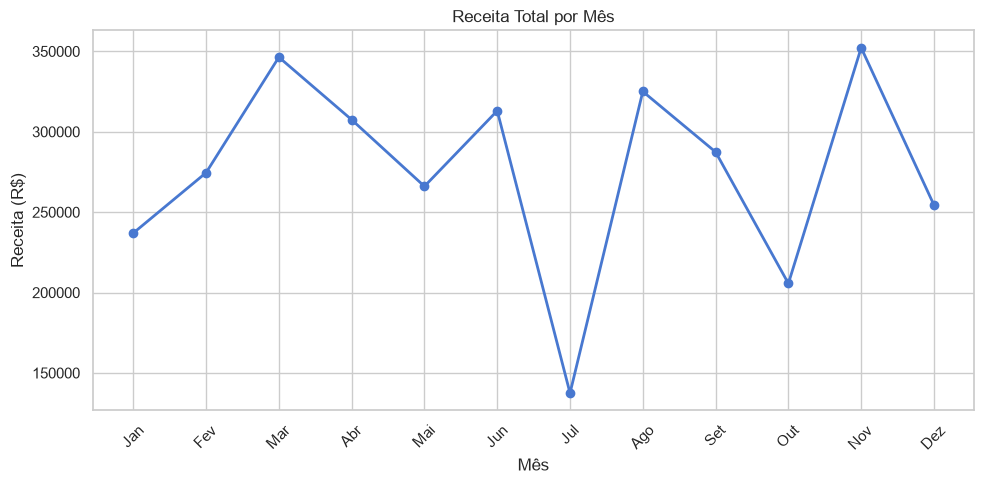

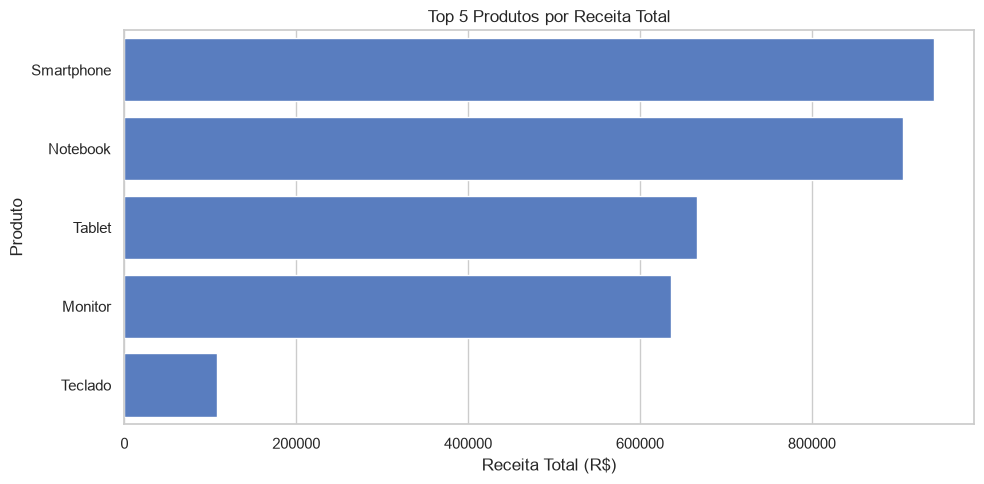

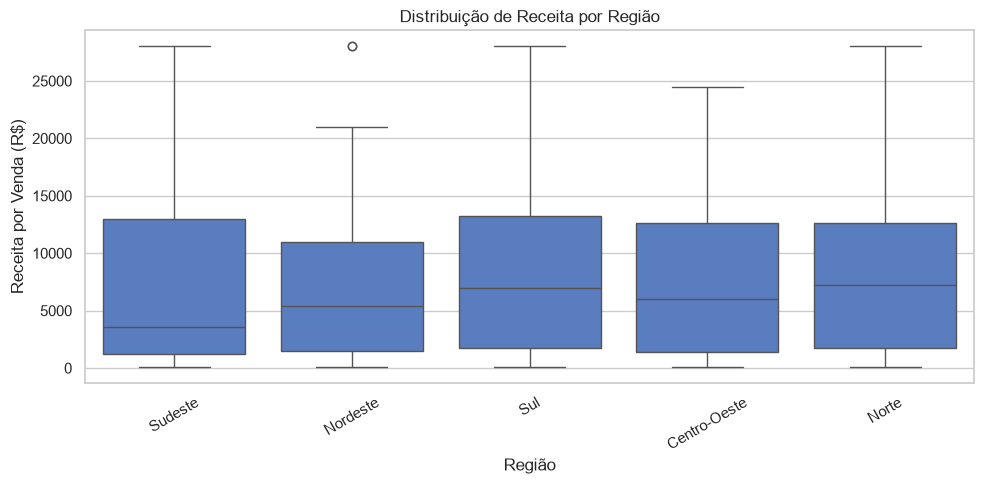

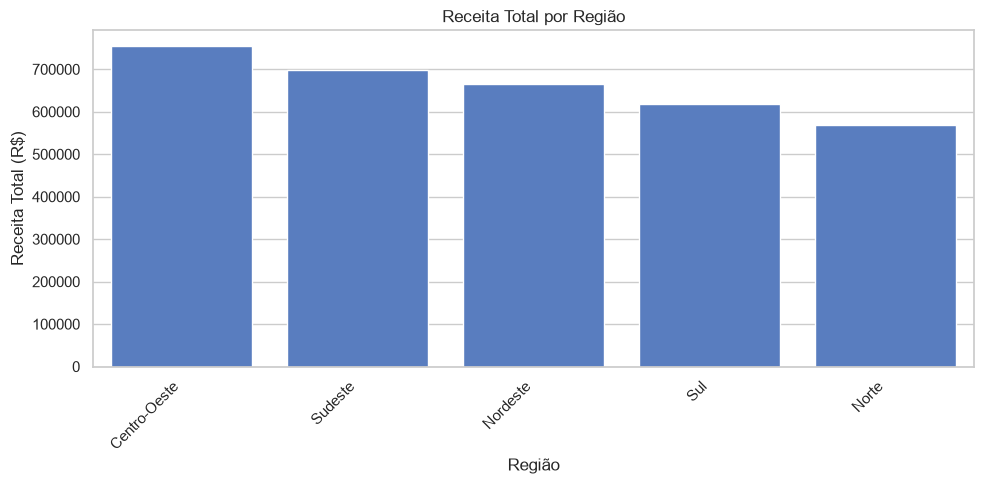

4 gráficos salvos em: outputs/graficos 


In [10]:


#1. Gráfico de linha : Receita total por mês ao longo do tempo
#2. Gráfico de barras : Top 5 produtos ou categorias por receita
#3. Gráfico Boxplot — Distribuição de Receita por Região
#4. Gráfico de barras (verticais), Receita Total por Região

import matplotlib.pyplot as plt
import seaborn as sns
import os

def gerar_visualizacoes ( df , metricas , output_dir = "outputs/graficos" ):
  #   Gera e exporta 3 gráficos informativos em PNG:
  #1. Linha — receita total por mês (tendência ao longo do tempo)
  #2. Barras — top 5 produtos por receita (ranking)
  #3. Boxplot — distribuição de receita por região (dispersão e outliers)
   #  sns.set_theme() aplica um estilo visual global a todos os gráficos
    # gerados na sessão — só precisa ser chamado uma vez."""

  os.makedirs(output_dir, exist_ok= True )
  sns.set_theme(style= "whitegrid" , palette= "muted" )
  meses_abrev = [ "Jan" , "Fev" , "Mar" , "Abr" , "Mai" , "Jun" , "Jul" , "Ago" , "Set" , "Out" , "Nov" , "Dez" ]

  # Gráfico 1: Linha — Receita por Mês - Ideal para mostrar tendência e sazonalidade ao longo do tempo

  fig, ax = plt.subplots(figsize=( 10 , 5 ))
  pm = metricas[ "por_mes" ]
  ax.plot(pm[ "mes" ], pm[ "receita_total" ], marker= "o" , linewidth= 2 )
  ax.set_title( "Receita Total por Mês" )
  ax.set_xlabel( "Mês" )
  ax.set_ylabel( "Receita (R$)" )
  ax.set_xticks( range ( 1 , 13 ))
  ax.set_xticklabels(meses_abrev, rotation= 45 )
  fig.tight_layout()
  fig.savefig( f"{output_dir}/receita_por_mes.png" , dpi= 120 )
  plt.show()
  plt.close() # libera memória da figura anterior antes de criar a próxima

  # Gráfico 2: Barras Horizontais — Top 5 Produtos
  # Barras horizontais facilitam a leitura de rótulos longos (nomes de produtos).

  fig, ax = plt.subplots(figsize=( 10 , 5 ))
  sns.barplot(data=metricas[ "top_produtos" ], y= "produto" , x= "receita_total" , ax=ax)
  ax.set_title( "Top 5 Produtos por Receita Total" )
  ax.set_xlabel( "Receita Total (R$)" )
  ax.set_ylabel( "Produto" )
  fig.tight_layout()
  fig.savefig( f"{output_dir}/top_produtos.png" , dpi= 120 )
  plt.show()
  plt.close()

  # Gráfico 3: Boxplot — Distribuição de Receita por Região
  # O boxplot mostra mediana, quartis e outliers de cada grupo,
  # permitindo comparar não só o volume mas a variação interna # de cada região — informação que um gráfico de barras não entrega.

  fig, ax = plt.subplots(figsize=( 10 , 5 ))
  sns.boxplot(data=df, x= "regiao" , y= "receita_total" , ax=ax)
  ax.set_title( "Distribuição de Receita por Região" )
  ax.set_xlabel( "Região" )
  ax.set_ylabel( "Receita por Venda (R$)" )
  plt.xticks(rotation= 30 )
  fig.tight_layout()
  fig.savefig( f"{output_dir}/dist_regiao.png" , dpi= 120 )
  plt.show()
  plt.close()


  # Gráfico 4: Barras verticais, Receita Total por Região

  fig, ax = plt.subplots(figsize=(10, 5))
  sns.barplot(data=metricas["por_regiao"], x="regiao", y="receita_total", ax=ax)
  ax.set_title("Receita Total por Região")
  ax.set_xlabel("Região")
  ax.set_ylabel("Receita Total (R$)")
  plt.xticks(rotation=45, ha='right')
  fig.tight_layout()
  fig.savefig(f"{output_dir}/receita_por_regiao.png", dpi=120)
  plt.show()
  plt.close()
  print ( f"4 gráficos salvos em: {output_dir} " )



gerar_visualizacoes(df, metricas)



#RF10 Organizar o Código em Funções Reutilizáveis

In [11]:


# O notebook está organizado de acordo com essas diretrizes. Para cada etapa da análise, criei uma função dedicada, conforme solicitado:
#- Criação de Funções para cada etapa: As funções gerar_dataset_vendas, inspecionar_dados, limpar_dados, tratar_outliers,
# criar_colunas_derivadas, calcular_metricas, segmentar_clientes, calcular_estatisticas_numpy e gerar_visualizacoes encapsulam todo o fluxo de análise.
#- Documentação com Docstrings: Todas as funções possuem docstrings detalhadas, explicando seu propósito e como funcionam.
#- Reutilização de Funções: A função limpar_dados é um exemplo de função reutilizada. Além disso, a arquitetura de passar df e
# metricas entre as funções criar_colunas_derivadas, calcular_metricas, segmentar_clientes, calcular_estatisticas_numpy e gerar_visualizacoes demonstra
# a reutilização do DataFrame principal e das métricas calculadas em diferentes contextos de análise e visualização.
#- Uso de Função Lambda: A segmentação de clientes na função segmentar_clientes utiliza uma expressão lambda para classificar os clientes com base
# em seus gastos totais.


#- função de ordem superior

#Uma função de ordem superior é uma função que **recebe outra função como argumento** (chamado de *callback*).
#Exemplo. `aplicar_transformacao(df, coluna, funcao)` aplica qualquer função que você passar a uma coluna. No exemplo,
#passamos uma `lambda` que classifica a venda em "Alto" ou "Normal". A vantagem: em vez de criar uma função nova para cada transformação,
#criamos **uma** que aceita qualquer regra.

def aplicar_transformacao(df, coluna, funcao):
    #"""Funcao de ordem superior: aplica qualquer funcao/lambda a uma coluna."""
    df = df.copy(); df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df

_demo = aplicar_transformacao(df, "receita_total", lambda x: "Alto" if x > 2000 else "Normal")
#_demo[["receita_total","receita_total_transformado"]].head()
print(_demo[["receita_total","receita_total_transformado"]].head())



   receita_total receita_total_transformado
0        17600.0                       Alto
1          500.0                     Normal
2        11000.0                       Alto
3         9600.0                       Alto
4         2200.0                       Alto


#RF11 Ler e Escrever Arquivos (CSV e JSON)

In [12]:


import json
import os
def exportar_resultados ( metricas , clientes , stats ):
  #""" Exporta os resultados da análise em dois formatos: - CSV : métricas mensais e segmentação de clientes
  #- JSON: estatísticas gerais calculadas com NumPy Após exportar o JSON, faz a leitura de volta com json.load()
  #para confirmar que o arquivo foi gravado corretamente — demonstrando leitura e escrita de JSON no mesmo fluxo. """

  os.makedirs( "outputs" , exist_ok= True )

  # --- Exportação CSV ---
  # encoding="utf-8-sig" adiciona um BOM (Byte Order Mark) ao arquivo.
  # Isso garante que o Excel abra o CSV com acentos corretamente;

  metricas[ "por_mes" ].to_csv( "outputs/metricas_por_mes.csv" , index= False , encoding= "utf-8-sig" )
  print ( "CSV exportado: outputs/metricas_por_mes.csv" )
  clientes.to_csv( "outputs/segmentacao_clientes.csv" , index= False , encoding= "utf-8-sig" )
  print ( "CSV exportado: outputs/segmentacao_clientes.csv" )



#RF12 Consolidar a Análise e Salvar o Dataset Final

In [13]:


#1. Todas as etapas do Notebook já foram executadas
#2. Esta célula salva o dataset final em data/final/
#3. Decisão de versão: Escolhi df_v2 (outliers removidos) como base da análise final

os.makedirs( "data/final" , exist_ok= True )
df.to_csv( "data/final/vendas_final.csv" , index= False )
print ( "Dataset final salvo em: data/final/vendas_final.csv" )

  # --- Exportação JSON ---
  # ensure_ascii=False permite gravar acentos como caracteres reais (ã, é)
  # round(float(v), 2) converte para float antes de arredondar,
  # evitando comportamento inesperado com o campo 'acima_da_media' (int).

stats_serializaveis = {k: round ( float (v), 2 ) for k, v in stats.items()}
caminho_json = "outputs/estatisticas_gerais.json"
with open (caminho_json, "w" , encoding= "utf-8" ) as f: json.dump(stats_serializaveis, f, indent= 2 , ensure_ascii= False )
  # indent=2 formata o JSON com recuo de 2 espaços, mais legível que uma linha só
print ( f"JSON exportado: {caminho_json} " )
  # --- Leitura de volta para confirmar ---
with open (caminho_json, encoding= "utf-8" ) as f: lido = json.load(f)
print ( "\nJSON lido de volta para confirmação:" )
print (json.dumps(lido, indent= 2 , ensure_ascii= False ))

exportar_resultados(metricas, clientes, stats)




Dataset final salvo em: data/final/vendas_final.csv
JSON exportado: outputs/estatisticas_gerais.json 

JSON lido de volta para confirmação:
{
  "media": 7690.0,
  "mediana": 6000.0,
  "desvio_padrao": 6985.79,
  "total": 3306700.0,
  "p25": 1500.0,
  "p75": 12600.0,
  "acima_da_media": 181.0
}
CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
